# How to use the quantum phase estimation framework

The experimental quantum phase estimation (QPE) implementation in PsiQDK Algorithms is designed to facilitate applications development by making it easy to define and work with complicated algorithms within QPE. This documentation page takes you through the framework, showing how it works and what objects make up the framework.

## Getting started – imports and structure
The experimental QPE framework lives in `psiqdk.algorithms.experimental.quantum_phase_estimation`. The module contains a lot of functionality, so for convenience we expose a single entrypoint for imports:

```python
from psiqdk.algorithms.experimental import quantum_phase_estimation as qpe
```

The module contains multiple sub-modules that are organized into:

- `presets`, which defines a builder for constructing QPE programs as well as a number of common use cases for convenient instantiation.
- `qpe_programs` which define the core functionality for the framework.
- `window_functions` which define different QPE window functions.
- `signal_generators` which are used to generate the signal in QPE, combining a time sampler, signal sampler and signal source state factory.
- `time_samplers` which are used to sample different points in time in QPE.
- `signal_source_states` which define different signal source states that are used to generate the signal in QPE.
- `frequency_resolvers` which define how the phase is to be post-processed in QPE.

For most people, the functionality exposed by the `QPEBuilder` and the `presets` is sufficient to accomplish most tasks. We'll focus on this aspect in the next section.

The sections after that go through the under-the-hood details of the implementation and are targeted at advanced users.

## QPEBuilder and presets — main entry point for using existing QPE functionality

The `qpe.presets` submodule exposes a `QPEBuilder` object that can be used to construct QPE programs for execution. This object provides a user-friendly interface for composing all the different objects required for building a full QPE program, as well as providing sensible defaults for common use cases.

In addition, the module provides a number of helper functions that return `QPEBuilder` classes for common use cases. The available presets are:

### Presets at a glance

| Preset | Role |
|--------|------|
| **`qpe.presets.phase_debug`** | QPE simulations with phasing operations applied directly onto the time-frequency register. Primarily aimed at state vector simulations and validation of other components (e.g. window functions). |
| **`qpe.presets.generic_unitary`** | Textbook QPE where the signal unitary is any Qubrick, QPU op or function. Every argument other than the two registers is frozen up front through `bound_arguments`. Of the two parameters left, the signal source register goes to the first one, and the time sample register goes to `ctrl`, `cond` or `condition_mask` if the op has one of those and to the next free parameter otherwise. |
| **`qpe.presets.diagonal_unitary`** | Textbook QPE using a diagonal unitary operation as the signal unitary. Primarily aimed at state vector simulations and validation of other components in the presence of noise (e.g. for imperfect signal source state preparation). |

Each preset has a number of keyword arguments that can be supplied to customize the implementation. All presets share the following key word arguments:

| Argument | Explanation |
|--------|------|
| **`bits_of_precision`** | The number of precision bits used in the QPE. |
| **`signal_source_state`** | Defines how the signal source state is to be supplied. Can be supplied as a `SignalSourceStateFactory` for fine-grained control, an iterable of coefficients to be directly injected (for state vector simulation) or simply a number of qubits to be initialized in $|0\rangle$. (Not used for the phase debug preset as there is no signal source state for that QPE setup). |
| **`window_function`** | **(optional)** Specifies which window function is to be used (defaults to `RectWindowV2`). |
| **`time_frequency_transformation`** | **(optional)** Specifies which time-frequency transformation is to be used (defaults to `QFT`). |

Additionally, each preset has a custom set of key word arguments specific to that operation (e.g. the `phase_debug` preset contains an `angle` key word argument). See the API reference documentation for a complete set of inputs.

For `generic_unitary`, the arguments of the op itself are passed as a dictionary through `bound_arguments` rather than as loose keyword arguments on the preset, e.g. `bound_arguments={"theta": 45.0}` to freeze the rotation angle of `Qubits.rz`. Every argument of the op other than the signal source register and the time sample register has to be supplied this way.

### Examples

Here we show two different setups, one for a generic unitary (we use `Rz`) and one for a phase debug setup.

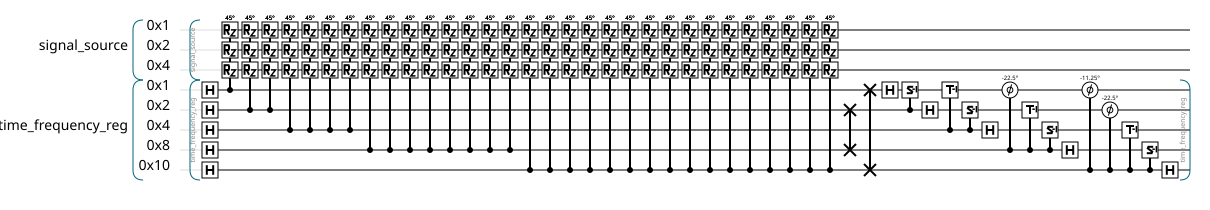

Most probable phase: 5.105088062083414


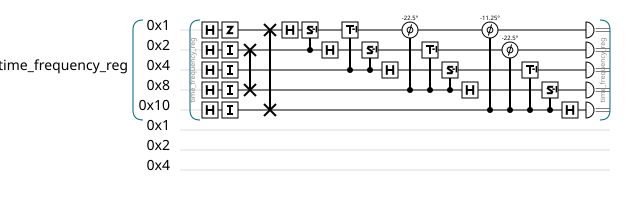

Most probable phase: 3.141592653589793


In [1]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.algorithms.experimental import quantum_phase_estimation as qpe

qpu = QPU(num_qubits=8)

program = (
    qpe.presets.generic_unitary(
        op=Qubits.rz,
        bits_of_precision=5,
        signal_source_state=qpe.ComputationalBasisStateFactory(3),
        bound_arguments={"theta": 45.0},
    )
    .with_debug_resolver()
    .build()
)

result = program(qpu)
qpu.draw()
print(f"Most probable phase: {result.get_most_probable_phase()}")


qpu = QPU(num_qubits=8)
program = (
    qpe.presets.phase_debug(angle=180, bits_of_precision=5)
    .with_measurement_based_resolver(num_shots=200)
    .build()
)

result = program(qpu)
qpu.draw()
print(f"Most probable phase: {result.get_most_probable_phase()}")

In the rest of this notebook, we'll go through the different options that are available to customize the QPE programs for different use cases.

## One level down: The QPE program

The object returned in the cells above from calling `QPEBuilder.build()` is a _QPE programme_. It is distinct from a Qubrick in that it also containerizes the repetitions of the algorithm needed to build up a full set of results. Currently, only one implementation (`QFTBasedQPE`) is supported, but more may be added as they are implemented.

### The `QPESubroutine` Qubrick
In addition to the full QPE program, we can also extract a Qubrick that encapsulates the main steps of QPE (i.e. window function application, signal generation and sampling and time-frequency transformation). This Qubrick is `QPESubroutine` and can be accessed via `QPEBuilder.qpe_subroutine`.

This is particularly useful if you need to use QPE coherently, e.g. as a subroutine in a larger algorithm.

## The easy stuff

Of the different components of a QPE program, two are much easier to reason about than the rest: the `WindowFunction` and `TimeFrequencyTransformation`. These are simple Qubricks that accept a time-frequency register (and an optional control) and perform their operation. For the purpose of this document, we won't say any more about these and will simply default to `RectWindowV2` and `QFT` for their implementations respectively.

## The signal source state factory

In software design, a factory function is a function that constructs some more complicated object. In this case, we need to define a function that accepts a QPU and returns a `Qubits` object encoding the signal source state to be used in QPE.

This can be as simple or as complex as is needed by the specific problem to be solved. In this case, we'll construct a signal source state by defining a classical state (which will be the eigenstate of our Hamiltonian when we hook everything together) and calling `ArbitraryStatePrep` to apply it onto a `Qubits` object that we initialize and return.


In [2]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.algorithms.experimental import StatePreparation
from psiqdk.algorithms.experimental.utils import StatePrepData


class ArbitraryStatePrepFactory:
    def __init__(self, prep_qbk: StatePreparation, prep_data: StatePrepData):
        self.prep_qbk = prep_qbk
        self.prep_data = prep_data

    def get_signal_source_state(self, qpu: QPU):
        qbts = Qubits((len(self.prep_data.coefficients) - 1).bit_length(), "signal_source", qpu)
        self.prep_qbk.compute(qbts, self.prep_data)
        return qbts


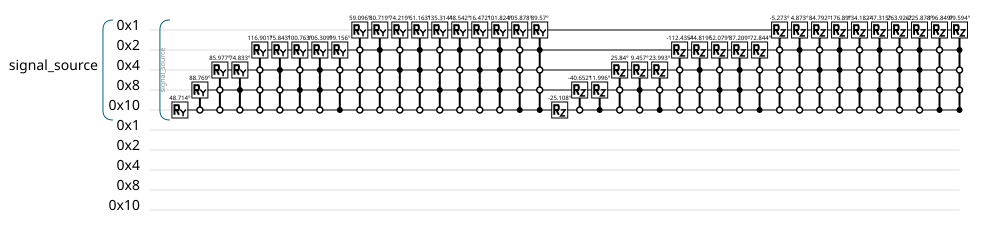

In [3]:
from psiqdk.workbench import QPU
from psiqdk.algorithms.experimental import (
    NaiveMultiplexedSingleQubitRotation,
    ProgrammableRotArray,
    ArbitraryStatePrep,
)
from psiqdk.algorithms.experimental.utils import ArbitraryStatePrepData, SupportedOps
import numpy as np

qpu = QPU(num_qubits=10)

rng = np.random.default_rng()

prep_coeffs = list(rng.uniform(-1, 1, 20) + 1j * rng.uniform(-1, 1, 20))
# we're going to use state vector efficient rotations, so epsilon is arbitrary here
prep_data = ArbitraryStatePrepData(prep_coeffs, 1e-1)

# note this will be less awkward with default dependencies
mplxr_instance = NaiveMultiplexedSingleQubitRotation()
amps_rot = ProgrammableRotArray(op=SupportedOps.RY, mplxr=mplxr_instance)
phases_rot = ProgrammableRotArray(op=SupportedOps.RZ, mplxr=mplxr_instance)
state_prep = ArbitraryStatePrep(amps_rot, phases_rot)
signal_source_state_factory = ArbitraryStatePrepFactory(state_prep, prep_data)

signal_source_reg = signal_source_state_factory.get_signal_source_state(qpu)

qpu.draw()


There are several things to note here:

1. Although we've defined a very simple signal source state setup, we could include things like auxiliary qubit allocation, calling sub-Qubricks etc.
2. We used the built-in Qubrick manager to get our Qubrick without having to explicitly define it. This is nice in this case, as `ArbitraryStatePrep` has quite a few details that we don't want to get bogged down in explicitly here.
3. The _only_ thing that the user needs to provide at setup is a QPU instance with sufficient qubits. Remember that the `get_signal_source_state` call happens _inside_ the QPE program.


## The signal generator

The signal generator did not appear as an argument in the `presets`, but it is arguably the most important part of the QPE framework. The signal generator determines:

- How time is sampled at each step of the subroutine.
- How the signal is generated at each step.
- How that signal gets propagated to the time-frequency register.

The reason that the signal generator is not included in the presets is that each signal generator has bespoke setup that is unique to each setting. This setup is abstracted away by the preset functions – thus each preset function corresponds to a different signal generator.

Nevertheless, it is possible to configure a signal generator manually, which we'll go through in the following steps. The necessary components are a _time sampler_ and a _signal sampler_, which must be composed together. The QPE framework exposes two methods by which this composition can be done: the `QPEBuilder` accepts time and signal samplers in its constructor, or alternatively you can instantiate a `SignalGenerator` class with a _sampling strategy_ that composes the samplers together.

This gives us three levels of control for building QPE programs:

1. If you have a well-known use case and just want to customize the window function, signal source state, time-frequency transformation etc, use a `preset`.
2. If you need to define a custom signal sampler and/or time sampler, but they compose in a standard way (i.e. the time sampler exposes some controls from the time-frequency register and the signal sampler performs some operations controlled on those qubits) then instantiate the samplers and pass them to the `QPEBuilder` directly.
3. If your signal generator is entirely custom, then you can define a custom sampling strategy to pass to the signal generator class. This would be the case for a signal generator that doesn't cleanly distinguish between time sampling and signal sampling (e.g. a signal sampler that uses all the qubits in the time-frequency register in a single step).

As you progress from level 1 to level 3, the degree of control you get increases, but the user-friendliness decreases. For most use cases, you shouldn't need to go beyond level 1, for some advanced use cases you might need level 2, and only the most advanced users should think about level 3 (and even then, only for specific problems).

In the following sections we'll go through the components needed for level 2.

## The time sampler

This defines the times in the time-frequency register over which we are going to obtain samples of the signal. The case we'll use here is textbook QPE, which utilizes a binary expansion of the times, applying the signal unitary $2^n$ times when the $n$th bit in the time-frequency register is set. This is exposed in the framework as `qpe.BitwiseTimeSampler`, but for demonstration we reproduce it here:

In [4]:
from typing import Any, Generator

from psiqdk.workbench import Qubits
from psiqdk.algorithms.experimental import quantum_phase_estimation as qpe


class BitwiseTimeSampler(qpe.TimeSampler):
    """Yields samples of the time-frequency register where each bit in the register is set.

    That is, on the nth iteration, yields the nth bit such that all time steps t for which
    `t & (1 << n) == 1` are sampled in superposition.

    Note:
        This is the "standard" sampling protocol that you see in, e.g. Nielsen and Chuang.
    """

    def _sample_from(self, time_frequency_register, qpe_config) -> Generator[Qubits, Any, Any]:
        # TODO: in a final implementation, we would also handle the adders for
        # non-power-of-two QPE here, but for now we just support power-of-two.
        for qubit in time_frequency_register:
            yield qubit


This is straightforward to use (although again, users won't be accessing this directly):

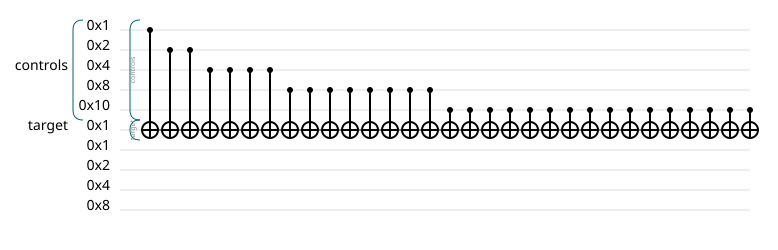

In [5]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.algorithms.experimental import quantum_phase_estimation as qpe

qpu = QPU(num_qubits=10)

controls = Qubits(5, "controls", qpu)
target = Qubits(1, "target", qpu)

time_sampler = BitwiseTimeSampler()

config = qpe.BitwiseQPEConfig(bits_of_precision=controls.num_qubits)

for i, control in enumerate(time_sampler.sample_from(controls, config)):
    for _ in range(config.get_num_iterations_per_time_step(i)):
        target.x(control)

qpu.draw()


This may seem a little over-engineered to loop over a `Qubits` register, but this design anticipates _unary QPE_, which has a far more complicated control structure. It also makes it easy to add new time samplers without having to change the wider QPE code.


## Signal sampler
The signal sampler is the complement of the time sampler: it creates an iterator that generates the signal for the corresponding step of the algorithm.

We can think of the interaction of these two iterators in mathematical (though still high-level) terms as follows:

- The time sampler iterates over various sets of times $\{\ket{t}\}$ according to different sampling strategies (e.g. for standard textbook QPE the sets of times yielded at step `n` are all those with a set bit in the `n`th position of their binary expansion).
- The signal sampler takes a set of times and applies the signal $S(t)$, realizing the mapping $\{\ket{t}\} \mapsto \{S(t)\ket{t}\}$.

When combined together, these realize the full operation

$$
\sum_{t=0}^{N-1}S(t)\ket{t} \ .
$$

In this example case, we'll follow textbook QPE and simply apply the signal unitary an exponential number of times depending on the step of the QPE (note that the number of sample times is set by the `BitwiseQPEConfig` class).


In [6]:
from typing import Callable

from psiqdk.workbench import BaseQubits, Qubits, Qubrick
from psiqdk.algorithms.experimental import quantum_phase_estimation as qpe

class GenericUnitarySignalSampler(qpe.SignalSampler[Qubits]):
    """This is an adaptor for handling generic, arbitrary unitaries for QPE.

    The op is either a callable taking the signal source register and the time
    sample register and nothing else, or a Qubrick that already has that shape:
    its `_compute` needs a `ctrl` parameter for the time sample register and one
    other parameter for the signal source register.

    Any other unitary has to have its remaining arguments frozen first, with
    `qpe.bind_generic_unitary_arguments`. The
    `generic_unitary` preset does this for you.

    While this is pretty generic and flexible, there are unitaries that can't
    easily be fit into this structure. The suggested API is to write a custom
    adaptor for whatever specific unitary you have in mind.

    Note:
        - For high performance applications, this is probably not the way to go.
        - We are not doing bidirectional phase kickback, as there is no generic
          way to do so.
        - This is only intended to support textbook (e.g. Nielsen and Chuang) QPE,
          with the exponentiation achieved by applying the unitary exponentially
          many times.
    """

    def __init__(self, op: Qubrick | Callable[[BaseQubits, BaseQubits], None]) -> None:
        if isinstance(op, Qubrick):
            # the real implementation also checks here that the Qubrick has a `ctrl`
            # parameter to receive the time sample register
            self.fn = qpe.bind_generic_unitary_arguments(op)
        elif callable(op):
            self.fn = op
        else:
            raise TypeError("GenericUnitarySignalSampler op must be a Qubrick or callable.")
        super().__init__()

    def _sample_signal(
        self,
        signal_source_register: Qubits,
        time_sample_register: Qubits,
        sample_step: int,
        qpe_config,
    ):
        for _ in range(qpe_config.get_num_iterations_per_time_step(sample_step)):
            self.fn(signal_source_register, time_sample_register)


Now that we have both a signal sampler and a time sampler, we can hook them up to construct a signal generator. Note that we didn't construct the signal generator directly here – this is a little awkward to do since the machinery is geared towards its integration in the signal generator. In practise, you'd pass the time and signal samplers to the `QPEBuilder` class and use the full QPE program or subroutine directly rather than using them independently like this.


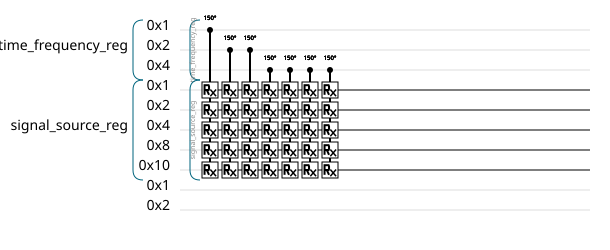

In [7]:
import numpy as np

from psiqdk.workbench import QPU, Qubits
from psiqdk.algorithms.experimental import quantum_phase_estimation as qpe

qpu = QPU(num_qubits=10)

time_frequency_reg = Qubits(3, "time_frequency_reg", qpu)
signal_source_reg = Qubits(5, "signal_source_reg", qpu)

time_sampler = qpe.BitwiseTimeSampler()

signal_sampler = GenericUnitarySignalSampler(
    qpe.bind_generic_unitary_arguments(Qubits.rx, theta=150)
)

signal_generator = qpe.SignalGenerator(qpe.SamplingStrategy(time_sampler, signal_sampler))

config = qpe.BitwiseQPEConfig(bits_of_precision=time_frequency_reg.num_qubits)

signal_generator.compute(time_frequency_reg, signal_source_reg, config)

qpu.draw()


This is now starting to look a bit crazy, but remember that _most of this isn't supposed to be touched by users directly_. Let's now skip ahead to the full implementation, where we can see the final piece of machinery introduced in this refactor: the frequency resolver.

In [8]:
import numpy as np

from psiqdk.workbench import QPU, Qubits
from psiqdk.algorithms.experimental import quantum_phase_estimation as qpe

bits_of_precision = 3
num_state_qubits = 2
phase_bits = [1, 0, 1]

qpu = QPU(num_qubits=bits_of_precision + num_state_qubits)

phase_bits += [0] * (bits_of_precision - len(phase_bits))
phase = sum(bit / (1 << (i + 1)) for i, bit in enumerate(phase_bits))

time_sampler = qpe.BitwiseTimeSampler()
signal_sampler = qpe.GenericUnitarySignalSampler(
    qpe.bind_generic_unitary_arguments(Qubits.rx, theta=phase * 2 * 360)
)
signal_generator = qpe.SignalGenerator(qpe.SamplingStrategy(time_sampler, signal_sampler))

frequency_resolver = qpe.DebugQFTQPEFrequencyResolver(frequency_interpreter=qpe.default_frequency_interpreter)

config = qpe.BitwiseQPEConfig(bits_of_precision=bits_of_precision)

qpe_subroutine = qpe.QPESubroutine(
    signal_generator,
    qpe.RectWindowV2(),
)
qpe_program = qpe.QFTBasedQPE(
    qpe.HadamardBasisStateFactory(num_state_qubits),
    qpe_subroutine,
    frequency_resolver=frequency_resolver,
    config=config,
)

result = qpe_program(qpu)

exp_phase = -2 * np.pi * (num_state_qubits * (phase / 2)) % (2 * np.pi)
resolution = 2 * np.pi * (1 / (1 << bits_of_precision))
assert (
    np.isclose(result.get_most_probable_phase(), exp_phase, atol= resolution)
    or np.isclose(result.get_most_probable_phase(), 2 * np.pi - exp_phase, atol= resolution)
)

Phew! That's quite a lot. But that's because we've broken down all the individual components and instantiated them independently before directly composing them. We can repeat the exact same simulation using the `qpe.presets.generic_unitary` preset to see how much simpler this pathway is:

In [9]:
import numpy as np

from psiqdk.workbench import QPU, Qubits
from psiqdk.algorithms.experimental import quantum_phase_estimation as qpe

bits_of_precision = 3
num_state_qubits = 2
phase_bits = [1, 0, 1]

qpu = QPU(num_qubits=bits_of_precision + num_state_qubits)

phase_bits += [0] * (bits_of_precision - len(phase_bits))
phase = sum(bit / (1 << (i + 1)) for i, bit in enumerate(phase_bits))

qpe_program = (
    qpe.presets.generic_unitary(
        op=Qubits.rx,
        bound_arguments={"theta": phase * 2 * 360},
        window_function=qpe.RectWindowV2(),
        signal_source_state=qpe.HadamardBasisStateFactory(num_state_qubits),
        bits_of_precision=bits_of_precision,
    )
    .with_debug_resolver()
    .build()
)

result = qpe_program(qpu)

exp_phase = -2 * np.pi * (num_state_qubits * (phase / 2)) % (2 * np.pi)
resolution = 2 * np.pi * (1 / (1 << bits_of_precision))
assert (
    np.isclose(result.get_most_probable_phase(), exp_phase, atol= resolution)
    or np.isclose(result.get_most_probable_phase(), 2 * np.pi - exp_phase, atol= resolution)
)

This now looks much nicer!

One pattern to look out for is that the different frequency resolvers are exposed as methods on the `QPEBuilder`, as seen in the method `with_debug_resolver` on the builder.